# Plant Disease Classification — MobileNetV2
##Dataset from Google Drive


In [ ]:
# Cell 1 — GPU check
import subprocess
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)


Sat May 16 08:17:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Cell 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 3 — Imports, seeds, mixed precision
import os, zipfile, shutil, random, json, itertools
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Compute dtype :', tf.keras.mixed_precision.global_policy().compute_dtype)
print('TensorFlow    :', tf.__version__)
print('GPUs          :', tf.config.list_physical_devices('GPU'))


Compute dtype : float16
TensorFlow    : 2.20.0
GPUs          : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 4 — Configuration (edit these)
ZIP_PATH        = '/content/drive/MyDrive/Plant_leave_diseases_dataset(WA).zip'
EXTRACT_DIR     = '/content/dataset'
FILTERED_DIR    = '/content/filtered_dataset'
CHECKPOINT_DIR  = '/content/drive/MyDrive/plant_checkpoints'
BEST_MODEL_PATH = '/content/drive/MyDrive/plant_best_model.keras'
EXPORT_DIR      = '/content/drive/MyDrive/plant_saved_model'

PLANTS      = ['Apple', 'Tomato', 'Potato', 'Strawberry']
IMG_SIZE    = 224
IMG_SHAPE   = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE  = 8
VAL_SPLIT   = 0.2

P1_LR       = 1e-3
P1_EPOCHS   = 15
P2_LR       = 1e-5
P2_EPOCHS   = 15
WEIGHT_DECAY = 1e-4
UNFREEZE_TOP = 50


In [ ]:
# Cell 5 — Extract ZIP and filter to 4 plants
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print('Extracting ZIP ...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

for junk in ['__MACOSX']:
    p = os.path.join(EXTRACT_DIR, junk)
    if os.path.exists(p):
        shutil.rmtree(p)

# Unwrap single-root ZIP
top = [d for d in os.listdir(EXTRACT_DIR) if os.path.isdir(os.path.join(EXTRACT_DIR, d))]
if len(top) == 1:
    root = os.path.join(EXTRACT_DIR, top[0])
    for item in os.listdir(root):
        shutil.move(os.path.join(root, item), EXTRACT_DIR)
    os.rmdir(root)

# Detect inner directory
inner = [d for d in os.listdir(EXTRACT_DIR) if os.path.isdir(os.path.join(EXTRACT_DIR, d))]
RAW_DIR = os.path.join(EXTRACT_DIR, inner[0]) if len(inner) == 1 else EXTRACT_DIR
print('Raw dir:', RAW_DIR)
print('All classes:', len(os.listdir(RAW_DIR)))

# Filter to 4 plants
if os.path.exists(FILTERED_DIR):
    shutil.rmtree(FILTERED_DIR)
os.makedirs(FILTERED_DIR, exist_ok=True)

copied = []
for folder in os.listdir(RAW_DIR):
    if any(folder.startswith(p) for p in PLANTS):
        shutil.copytree(os.path.join(RAW_DIR, folder),
                        os.path.join(FILTERED_DIR, folder))
        copied.append(folder)

print(f'Filtered classes ({len(copied)}):', sorted(copied))


Extracting ZIP ...
Raw dir: /content/dataset
All classes: 20
Filtered classes (19): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
# Cell 6 — Build tf.data pipelines
AUTOTUNE = tf.data.AUTOTUNE

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.12),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.15),
], name='augmentation')

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = augmentation(image, training=True)
    return image, label

def preprocess_val(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

load_kwargs = dict(image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, seed=SEED)

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    FILTERED_DIR, validation_split=VAL_SPLIT,
    subset='training', shuffle=True, **load_kwargs)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    FILTERED_DIR, validation_split=VAL_SPLIT,
    subset='validation', shuffle=False, **load_kwargs)

assert train_ds_raw.class_names == val_ds_raw.class_names
CLASS_NAMES = train_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

STEPS_PER_EPOCH = tf.data.experimental.cardinality(train_ds_raw).numpy()
VAL_STEPS       = tf.data.experimental.cardinality(val_ds_raw).numpy()
print(f'Classes: {NUM_CLASSES}  |  Train batches: {STEPS_PER_EPOCH}  |  Val batches: {VAL_STEPS}')

train_ds = train_ds_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(preprocess_val,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


Found 25048 files belonging to 19 classes.
Using 20039 files for training.
Found 25048 files belonging to 19 classes.
Using 5009 files for validation.
Classes: 19  |  Train batches: 1253  |  Val batches: 314


Batch shape : (16, 224, 224, 3)  |  dtype: <dtype: 'float16'>
Pixel range : [0.000, 0.945]


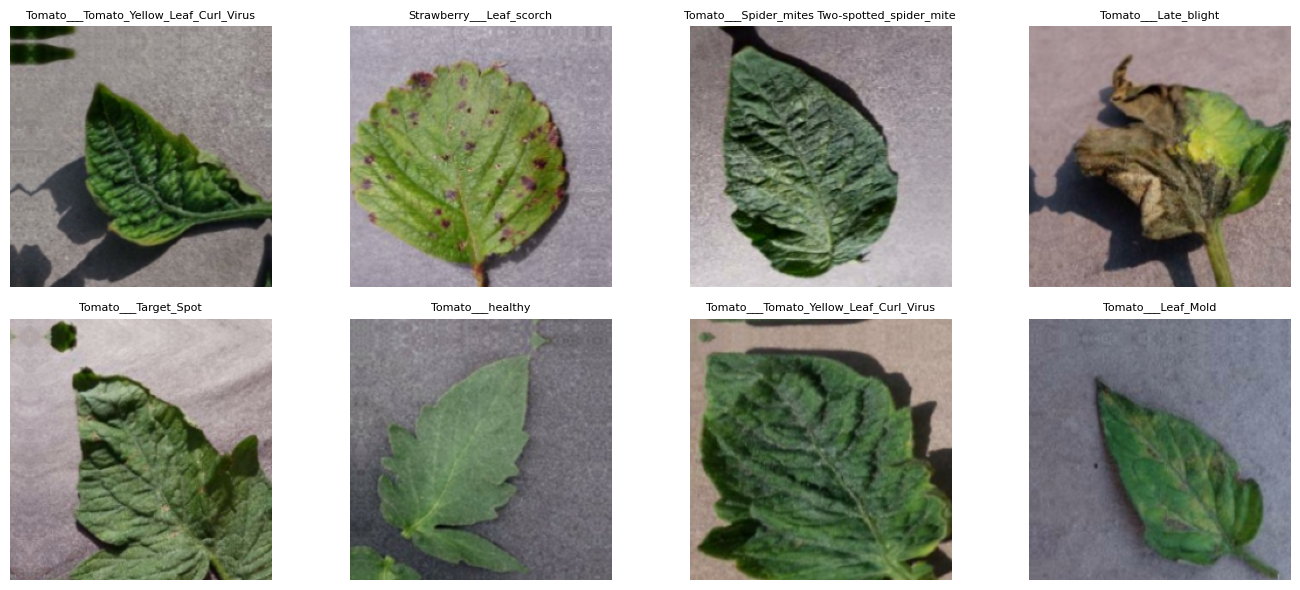

In [ ]:
# Cell 7 — Sanity check batch
imgs, lbls = next(iter(train_ds))
print(f'Batch shape : {imgs.shape}  |  dtype: {imgs.dtype}')
print(f'Pixel range : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]')

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flat, imgs[:8], lbls[:8]):
    ax.imshow(np.clip(img.numpy().astype(np.float32), 0, 1))
    ax.set_title(CLASS_NAMES[lbl], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Cell 8 — Class weight computation
all_labels = []
for _, lbls in train_ds_raw:
    all_labels.extend(lbls.numpy().tolist())

unique = np.unique(all_labels)
weights = compute_class_weight(class_weight='balanced', classes=unique, y=all_labels)
CLASS_WEIGHTS = dict(zip(unique.tolist(), weights.tolist()))

print('Class weights:')
for i, w in CLASS_WEIGHTS.items():
    print(f'  {CLASS_NAMES[i]:40s} → {w:.4f}')


Class weights:
  Apple___Apple_scab                       → 2.0802
  Apple___Black_rot                        → 2.1393
  Apple___Cedar_apple_rust                 → 4.6056
  Apple___healthy                          → 0.7990
  Potato___Early_blight                    → 1.3021
  Potato___Late_blight                     → 1.3317
  Potato___healthy                         → 8.7164
  Strawberry___Leaf_scorch                 → 1.1917
  Strawberry___healthy                     → 2.8660
  Tomato___Bacterial_spot                  → 0.6079
  Tomato___Early_blight                    → 1.2815
  Tomato___Late_blight                     → 0.7008
  Tomato___Leaf_Mold                       → 1.3951
  Tomato___Septoria_leaf_spot              → 0.7448
  Tomato___Spider_mites Two-spotted_spider_mite → 0.7698
  Tomato___Target_Spot                     → 0.9325
  Tomato___Tomato_Yellow_Leaf_Curl_Virus   → 0.2482
  Tomato___Tomato_mosaic_virus             → 3.5996
  Tomato___healthy                         →

In [ ]:
# Cell 9 — Build model (Phase 1: frozen backbone)
def build_model(num_classes, trainable_backbone=False):
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE,
        alpha=1.4,
        include_top=False,
        pooling='avg',
        weights='imagenet',
    )
    backbone.trainable = trainable_backbone

    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=IMG_SHAPE),
        backbone,
        tf.keras.layers.Dropout(0.3, name='head_dropout1'),
        tf.keras.layers.Dense(256, name='head_fc'),
        tf.keras.layers.BatchNormalization(name='head_bn'),
        tf.keras.layers.Activation('relu', name='head_relu'),
        tf.keras.layers.Dropout(0.2, name='head_dropout2'),
        tf.keras.layers.Dense(num_classes, activation='softmax',
                              dtype='float32', name='predictions'),
    ], name='plant_mobilenetv2')
    return model

model = build_model(NUM_CLASSES, trainable_backbone=False)
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
total     = model.count_params()
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')


Total params     : 4,828,627
Trainable params : 464,403  (9.6%)


In [ ]:
# Cell 10 — Phase 1 compile (frozen backbone, warm-up head)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=P1_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

p1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, 'p1_best.keras'),
        monitor='val_acc', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_acc', patience=5,
        restore_best_weights=True, mode='max', verbose=1),
    # ReduceLROnPlateau removed — cleaner Phase 1 convergence
    tf.keras.callbacks.CSVLogger('/content/p1_log.csv'),
]

print('Phase 1 compiled (frozen backbone).')


Phase 1 compiled (frozen backbone).


In [ ]:
# Cell 11 — Phase 1 training
print(f'Phase 1: training head only for up to {P1_EPOCHS} epochs ...')
history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=P1_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=p1_callbacks,
    verbose=1,
)
print(f'Phase 1 best val_acc: {max(history_p1.history["val_acc"])*100:.2f}%')


Phase 1: training head only for up to 15 epochs ...
Epoch 1/15
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - acc: 0.6635 - loss: 1.1044
Epoch 1: val_acc improved from None to 0.93691, saving model to /content/drive/MyDrive/plant_checkpoints/p1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_checkpoints/p1_best.keras
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 499s 367ms/step - acc: 0.7610 - loss: 0.7480 - val_acc: 0.9369 - val_loss: 0.2110 - learning_rate: 0.0010
Epoch 2/15
1252/1253 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - acc: 0.8291 - loss: 0.4915
Epoch 2: val_acc improved from 0.93691 to 0.94869, saving model to /content/drive/MyDrive/plant_checkpoints/p1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_checkpoints/p1_best.keras
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 417s 325ms/step - acc: 0.8343 - loss: 0.4763 - val_acc: 0.9487 - val_loss: 0.1818 - learning_rate: 0.0010
Epoch 3/15
1252/1253 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - acc: 0.8496 - loss: 0.422

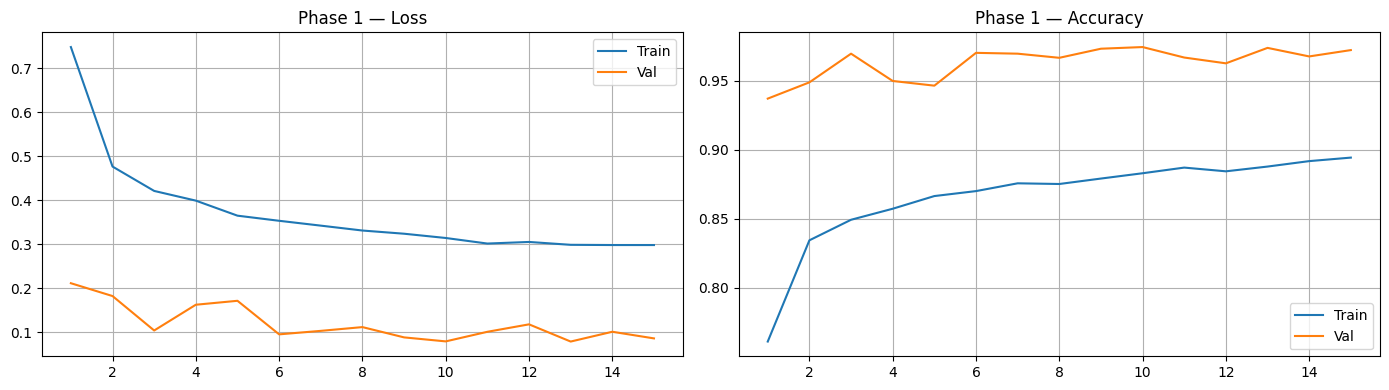

In [ ]:
# Cell 12 — Plot Phase 1 curves
def plot_history(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(hist['loss']) + 1)
    axes[0].plot(epochs, hist['loss'], label='Train')
    axes[0].plot(epochs, hist['val_loss'], label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(epochs, hist['acc'], label='Train')
    axes[1].plot(epochs, hist['val_acc'], label='Val')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()

plot_history(history_p1.history, 'Phase 1')


In [ ]:
# Cell 13 — Fine-tune: unfreeze top UNFREEZE_TOP layers of backbone
backbone = model.layers[0]  # MobileNetV2 is first layer in Sequential
backbone.trainable = True

for layer in backbone.layers[:-UNFREEZE_TOP]:
    layer.trainable = False

trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
total     = model.count_params()
print(f'Unfrozen top {UNFREEZE_TOP} backbone layers')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')


Unfrozen top 50 backbone layers
Trainable params : 3,970,323  (82.2%)


In [ ]:
# Cell 14 — Phase 2 compile (cosine LR decay + AdamW)
total_steps  = STEPS_PER_EPOCH * P2_EPOCHS
warmup_steps = STEPS_PER_EPOCH * 2

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0,
    decay_steps=total_steps - warmup_steps,
    alpha=1e-6,
    warmup_target=P2_LR,
    warmup_steps=warmup_steps,
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
)

p2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_acc', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_acc', patience=8,
        restore_best_weights=True, mode='max', verbose=1),
    # ReduceLROnPlateau REMOVED — crashes with CosineDecay schedule
    tf.keras.callbacks.CSVLogger('/content/p2_log.csv'),
    tf.keras.callbacks.TensorBoard(log_dir='/content/tb_logs',
                                   histogram_freq=0, write_graph=False),
]

print('Phase 2 compiled (fine-tune top layers).')

Phase 2 compiled (fine-tune top layers).


In [ ]:
# Cell 15 — Phase 2 training (Fine Tuning)
print(f'Phase 2: fine-tuning top {UNFREEZE_TOP} layers for up to {P2_EPOCHS} epochs ...')
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=P2_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=p2_callbacks,
    verbose=1,
)
print(f'Phase 2 best val_acc: {max(history_p2.history["val_acc"])*100:.2f}%')

Loading best checkpoint (epoch 12, val_acc 98.76%) ...
Trainable params: 3,970,323
Resuming fine-tune for 3 more epochs ...
Epoch 1/3
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - acc: 0.9669 - loss: 0.0960
Epoch 1: val_acc improved from None to 0.98762, saving model to /content/drive/MyDrive/plant_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_best_model.keras
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 522s 372ms/step - acc: 0.9679 - loss: 0.0856 - val_acc: 0.9876 - val_loss: 0.0391
Epoch 2/3
1252/1253 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - acc: 0.9715 - loss: 0.0746
Epoch 2: val_acc did not improve from 0.98762
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 396s 316ms/step - acc: 0.9722 - loss: 0.0751 - val_acc: 0.9876 - val_loss: 0.0401
Epoch 3/3
1252/1253 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - acc: 0.9700 - loss: 0.0823
Epoch 3: val_acc improved from 0.98762 to 0.98862, saving model to /content/drive/MyDrive/plant_best_model.keras

Epoch 3: finished saving model to /content/driv

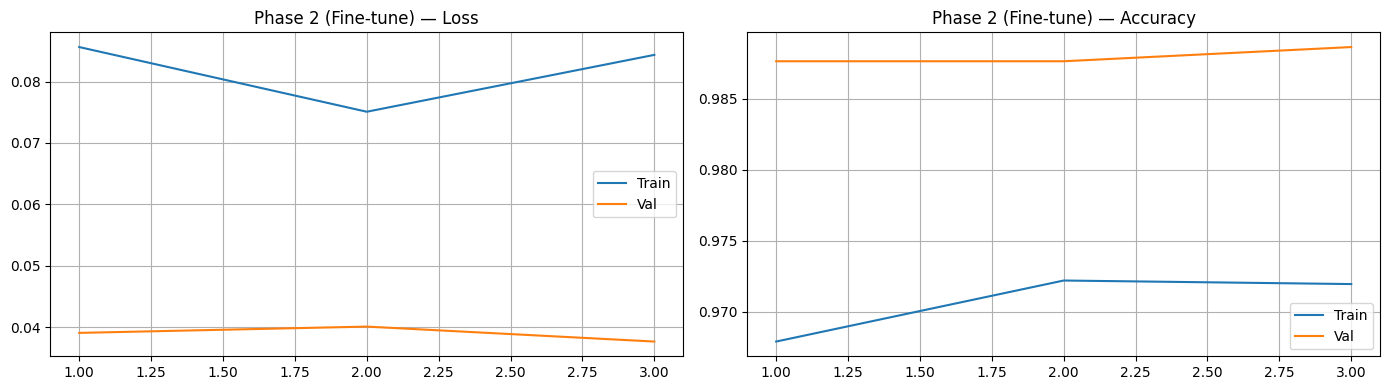

In [ ]:
# Cell 16 — Plot Phase 2 curves
plot_history(history_p2.history, 'Phase 2 (Fine-tune)')


In [ ]:
# Cell 17 — Full evaluation
results = model.evaluate(val_ds, verbose=1)
for name, val in zip(model.metrics_names, results):
    print(f'  {name}: {val:.4f}')


314/314 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - acc: 0.9886 - loss: 0.0376
  loss: 0.0376
  compile_metrics: 0.9886


In [ ]:
# Cell 19 — Save model + class names
os.makedirs(EXPORT_DIR, exist_ok=True)
model.export(EXPORT_DIR)
model.save(BEST_MODEL_PATH)

with open('/content/drive/MyDrive/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

print(f'Keras model  : {BEST_MODEL_PATH}')
print(f'SavedModel   : {EXPORT_DIR}')
print('class_names.json saved.')


Saved artifact at '/content/drive/MyDrive/plant_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 19), dtype=tf.float32, name=None)
Captures:
  140491507958416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507959568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507959376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507958992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507960144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507960528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507960720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507959760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507960336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140491507961296: TensorSpec(shape=(), dtype=tf.resource, n

In [ ]:
# Cell 21 — Download artifacts
from google.colab import files
files.download('/content/p1_log.csv')
files.download('/content/p2_log.csv')
print('Files downloaded. Keras model is in your Google Drive.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded. Keras model is in your Google Drive.
